In [3]:
import glob
import os
import sys
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, linregress, norm, fisher_exact, mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.interpolate import make_interp_spline, BSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk


sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile


plt.rcParams['font.family'] = 'Helvetica'#'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica' #'Times New Roman'
font1 = {'color':'black','size':20, 'family':'Helvetica'}
font2 = {'color':'black','size':20, 'family':'Helvetica'}

color1 = '#1B7F79' #deep teal
color2 = '#E07B39' #soft orange
color3 = '#4C6EF5' # Slate Blue
color4 = '#E0A458' # Amber Gold
color5 = '#2F3E46' # Muted Navy Blue
color6 = '#7A8A8F' # Warm Slate Gray
color7 = '#8B6F9C' # Dusty Purple
color8 = '#8FA98C' # Olive Green (Desaturated)
color9 = '#E6D8B8' # Warm Beige
color10 = '#4D4D4D' # Dark Gray
color11 = '#009E73' # Bluish Green

color_set1 = ['#8FBCBB', '#BF616A', '#5E81AC']

In [ ]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"

metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

mkdir: /Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/MappedPreCABG: File exists


In [5]:
print(PatientMetadata)

   patient-id stenosis tag   graft severity-anatomical (%)  is-ischemic  \
0        SU03         Diag  Radial                     100         True   
1        SU03          LAD    LIMA                      70         True   
2        SU03          RCA     SVG                     100         True   
3        SU04          LAD    LIMA                      80         True   
4        SU04          LCx  Radial                      80         True   
..        ...          ...     ...                     ...          ...   
70       VA08          LCx     SVG                       n         True   
71       VA08          RCA     SVG                       n         True   
72       VA20          LAD    LIMA                       n         True   
73       VA20          LCx     SVG                       n         True   
74       VA20          RCA     SVG                       n         True   

    cutoff   NG Note  graft-stenosis  
0       90   IM  NaN               0  
1       90  OM1  NaN 

In [6]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [7]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def robust_mode(data, bins=50):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_bin_index = np.argmax(counts)
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    return mode_value

def Normalize(MBF, method="mode", cutoff = 50):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(MBF, ArrayName, cutoff))
    HealthyMyo = LargestConnectedRegion(ThresholdInBetween(MBF, ArrayName, np.percentile(ScalarArray,10), np.percentile(ScalarArray,90)))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(HealthyMyo, ArrayName, cutoff))
    ScalarArray_healthy = vtk_to_numpy(HealthyMyo.GetPointData().GetArray(ArrayName))
    
    if method == "mode": # Histogram Analysis
        # Using Freedman-Diaconis Rule to calculate the number of bins based on IQR
        IQR = np.percentile(ScalarArray_healthy, 75) - np.percentile(ScalarArray_healthy, 25)
        bin_width = 2*IQR/(len(ScalarArray_healthy))**(1/3)
        MBF_range = np.max(ScalarArray_healthy) - np.min(ScalarArray_healthy)
        bins = int(MBF_range/bin_width)
        ref_MBF = robust_mode(ScalarArray_healthy, bins)
    elif method == "median":
        ref_MBF = np.median(ScalarArray_healthy)
    elif method == "mean":
        ref_MBF = np.mean(ScalarArray_healthy)
    elif method == "classic":
        ref_MBF = np.percentile(ScalarArray, 75)
    elif method == "zscore":
        q1, q2, q3 = np.percentile(ScalarArray_healthy, [25, 50, 75])
        IndexMBFArray = (ScalarArray - q2)/(q3 - q1)
        IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
        IndexMBF = numpy_to_vtk(IndexMBFArray)
        IndexMBF.SetName("IndexMBF")
        MBF.GetPointData().AddArray(IndexMBF)

        return MBF
    else:
        ref_MBF = np.percentile(ScalarArray_healthy, 75)

    IndexMBFArray = ScalarArray/ref_MBF
    #IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF

def GetVolume(Grid):
    Volume = 0
    for i in range(Grid.GetNumberOfCells()):
        voxel = Grid.GetCell(i)
        cell_bounds = voxel.GetBounds()
        Volume += abs(cell_bounds[0] - cell_bounds[1]) * abs(cell_bounds[2] - cell_bounds[3]) * abs(cell_bounds[4] - cell_bounds[5])
    
    return Volume

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)
    

    return AbsMBFData, IndexMBFData

def GetRegionVolume(MBF, Labels, key):
    volume = 0

    for i in Labels[key]:
        territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
        volume += GetVolume(territory_)
    
    return volume

def BoxPlot(DataFrame):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='Territories', y='MBF', hue='Type', data= DataFrame, showfliers=False, palette={'A':'skyblue', 'B':'salmon'})

    ax.set_ylabel("Index MBF", fontsize = 20)
    ax.tick_params(axis='x', rotation=10, labelsize=15)
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

def ViolinPlot(DataFrame):
    plt.figure(figsize=(7.5, 5.5))

    sns.violinplot(x='Territories', y='MBF', hue='Type', data = DataFrame, split=True, inner = 'quartiles', bw_adjust = 10, common_norm=True, linewidth=2.5, fill= False, gap=.1, palette={'Baseline':color1, 'Follow-up':color2})

    plt.ylabel("Myocardial Blood Flow\n(mL/min/100mL)", fontsize = 23)
    plt.tick_params(axis= 'x', labelsize = 18)
    plt.xticks(fontsize = 20, rotation=90)
    plt.yticks(fontsize = 18)
    #plt.xlabel("Group")
    plt.legend(fontsize = 16, loc="upper left")
    plt.ylim([-200, 600])
    plt.show()

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    return meanB + (stdB/stdA)*(DataA - meanA)

def Map3DVolume(meanA, meanB, stdA, stdB, VolumeA):
    for i in range(VolumeA.GetPointData().GetNumberOfArrays()):
            arrayname_ = VolumeA.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(VolumeA.GetPointData().GetArray(ScalarArray))
    ScalarData_Mapped = numpy_to_vtk(MapNongrafted(meanA, meanB, stdA, stdB, ScalarData))
    MappedScalarArrayName = "MappedScalar"
    ScalarData_Mapped.SetName(MappedScalarArrayName)
    VolumeA.GetPointData().AddArray(ScalarData_Mapped)

    return VolumeA

def ShiftMBF(refA, refB, DataA):
    return DataA - (refA - refB)

def ReturnMedianMBF(Volume):
    for i in range(Volume.GetPointData().GetNumberOfArrays()):
        arrayname_ = Volume.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(Volume.GetPointData().GetArray(ScalarArray))
    return np.median(ScalarData)

def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2, nan_policy='omit', zero_method='pratt')
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value

def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_

def GetMBFArray(VTUVolume):
    ScalaraArrayName = GetScalarArrayName(VTUVolume)
    MBF_array = vtk_to_numpy(VTUVolume.GetPointData().GetArray(ScalaraArrayName))
    return MBF_array

In [8]:
print(PatientMetadata[PatientMetadata['patient-id'] == 'SU03']['stenosis tag'])

0    Diag
1     LAD
2     RCA
Name: stenosis tag, dtype: str


In [9]:
# Cases that didn't reach hyperaemia
Removed_Cases = ["SU25", "VA04"]

In [12]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A, IndexMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B, IndexMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    ref_A = np.median(array_A)
    # mean_A = np.mean(array_A)
    # std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    ref_B = np.median(array_B)
    # mean_B = np.mean(array_B)
    # std_B = np.std(array_B)

    # t = "Non-grafted\nstenosis>50%"
    # if t in MBF_Labels.keys():
    #     array_A_ = AbsMBFData_A[t]
    # mbf_median_non_grafted = np.median(MapNongrafted(mean_A, mean_B, std_A, std_B, np.concatenate([array_A, array_A_])))


    MBF_A_array = GetMBFArray(MBF_A)
    MBF_B_Array = GetMBFArray(MBF_B)

    # ref_A = np.percentile(MBF_A_array, 50)
    # ref_B = np.percentile(MBF_B_Array, 50)

    ref = np.percentile(MBF_A_array, 75)

    threshold1 = 0.9 * ref  # 10% drop
    threshold2 = 0.8 * ref  # 20% drop
    threshold3 = 0.7 * ref  # 30% drop

    for i, t in enumerate(tags):
        mbf_median = np.median(AbsMBFData_A[t])
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = False
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3


        array_B = ShiftMBF(ref_B, ref_A, AbsMBFData_B[t]) # MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": AbsMBFData_A[t], "absMBF_B": array_B, "median_A": np.median(AbsMBFData_A[t]), "median_B": np.median(array_B)}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_B = ShiftMBF(ref_B, ref_A, AbsMBFData_B[t]) # MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": array_B, "median_A": np.median(AbsMBFData_A[t]), "median_B": np.median(array_B)}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    array_B = ShiftMBF(ref_B, ref_A, AbsMBFData_B[t]) # MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": array_B, "median_A": np.median(AbsMBFData_A[t]), "median_B": np.median(array_B)}
    dataMapped.append(data_)


In [13]:
df = pd.DataFrame(dataMapped)

In [86]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[df['is_ischemic'] == True]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("ischemic_grafted_A", q2, q3-q1, average, std)

mbf_ischemic_B = np.concatenate(df[df['is_ischemic'] == True]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("ischemic_grafted_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)

mbf_st_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_A)
std = np.std(mbf_st_nongrafted_A)
print("stenosed_nongrafted_A", q2, q3-q1, average, std)

mbf_st_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_B)
std = np.std(mbf_st_nongrafted_B)
print("stenosed_nongrafted_B", q2, q3-q1, average, std)

mbf_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_nongrafted_A)
std = np.std(mbf_nongrafted_A)
print("nongrafted_A", q2, q3-q1, average, std)

mbf_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_nongrafted_B)
std = np.std(mbf_nongrafted_B)
print("nongrafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted_A 105.0 70.0 121.73544905113107 70.46345921208717
ischemic_grafted_B 115.0 71.0 129.16381136594663 66.06474723407955
nonischemic_grafted_A 126.0 54.0 135.45412686673012 52.845149133591946
nonischemic_grafted_B 121.0 70.0 131.35778487357786 59.01796303582775
stenosed_nongrafted_A 120.0 73.0 136.28203037095275 71.32863030456936
stenosed_nongrafted_B 119.0 83.0 131.8834069464947 70.52905301368251
nongrafted_A 121.0 70.0 135.49542030642618 66.1213015925952
nongrafted_B 121.0 67.0 134.76655423222573 65.41632887065866


In [87]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_A, mbf_nonischemic_A, mbf_st_nongrafted_A, mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_A) + len(mbf_nonischemic_A) + len(mbf_st_nongrafted_A) + len(mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_B, mbf_nonischemic_B, mbf_st_nongrafted_B, mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic_B) + len(mbf_nonischemic_B) + len(mbf_st_nongrafted_B) + len(mbf_nongrafted_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

In [88]:
median_mbf_ischemic_A = df[df['is_ischemic'] == True]['median_A']
median_mbf_ischemic_B = df[df['is_ischemic'] == True]['median_B']

median_mbf_nonischemic_A = df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['median_A']
median_mbf_nonischemic_B = df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['median_B']

median_mbf_st_nongrafted_A = df[df['tag'] == 'Non-grafted\nstenosis>50%']['median_A']
median_mbf_st_nongrafted_B = df[df['tag'] == 'Non-grafted\nstenosis>50%']['median_B']

median_mbf_nongrafted_A = df[df['tag'] == 'Non-grafted\nstenosis<50%']['median_A']
median_mbf_nongrafted_B = df[df['tag'] == 'Non-grafted\nstenosis<50%']['median_B']


In [89]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([median_mbf_ischemic_A, median_mbf_nonischemic_A, median_mbf_st_nongrafted_A, median_mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(median_mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(median_mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(median_mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(median_mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(median_mbf_ischemic_A) + len(median_mbf_nonischemic_A) + len(median_mbf_st_nongrafted_A) + len(median_mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([median_mbf_ischemic_B, median_mbf_nonischemic_B, median_mbf_st_nongrafted_B, median_mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(median_mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(median_mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(median_mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(median_mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(median_mbf_ischemic_B) + len(median_mbf_nonischemic_B) + len(median_mbf_st_nongrafted_B) + len(median_mbf_nongrafted_B))
})

df_long2 = pd.concat([df_A, df_B], ignore_index=True)

In [90]:
# 1. Calculate lengths of your 4 distinct blocks
len_isch = len(median_mbf_ischemic_A)
len_nonisch = len(median_mbf_nonischemic_A)
len_st = len(median_mbf_st_nongrafted_A)
len_nongraft = len(median_mbf_nongrafted_A)

# 2. Create tracking IDs matching those exact block sizes
ids_ischemic = [f"isch_{i}" for i in range(len_isch)]
ids_nonischemic = [f"nonisch_{i}" for i in range(len_nonisch)]
ids_st_nongrafted = [f"st_nongraft_{i}" for i in range(len_st)]
ids_nongrafted = [f"nongraft_{i}" for i in range(len_nongraft)]

# 3. Combine them to match one full dataframe size
master_ids = ids_ischemic + ids_nonischemic + ids_st_nongrafted + ids_nongrafted

# 4. Duplicate the IDs because df_long2 stacks df_A and df_B perfectly in half
df_long2['ID'] = master_ids + master_ids

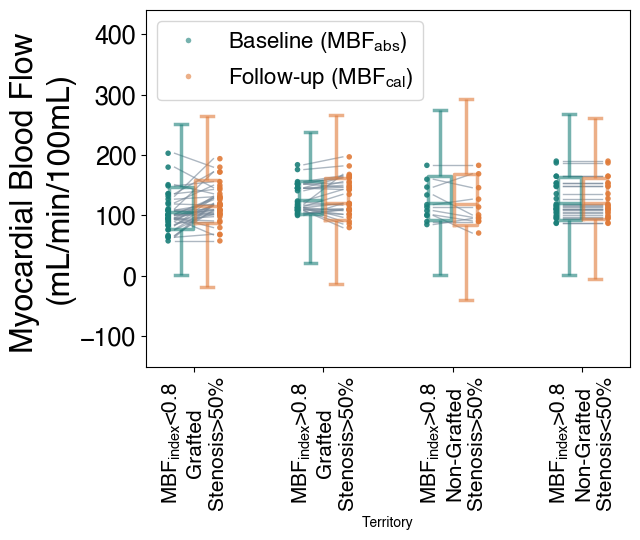

In [91]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2}, legend=False)#, boxprops=dict(alpha=0.4))
sns.stripplot(x='Territory', y='MBF', hue='Type', data= df_long2, dodge=True, jitter=False, alpha=0.9, size=4, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})
#ax = plt.gca()

# Group by territory to iterate over the 4 categorical columns
for i, territory in enumerate(df_long2['Territory'].unique()):
    df_terr = df_long2[df_long2['Territory'] == territory]
    
    # Pair up every unique patient ID within this territory
    for pid in df_terr['ID'].unique():
        pair = df_terr[df_terr['ID'] == pid]
        
        # Verify both pre and post points exist for the ID
        if len(pair) == 2:
            val_base = pair[pair['Type'].str.contains('Baseline')]['MBF'].values[0]
            val_foll = pair[pair['Type'].str.contains('Follow-up')]['MBF'].values[0]
            
            # Compute shifted x positions matching the 0.3 dodge factor
            x_base = i - 0.15 
            x_foll = i + 0.15
            
            # Draw the connecting paired line
            ax.plot([x_base, x_foll], [val_base, val_foll], color='lightslategray', alpha=0.6, linewidth=1, zorder=1)

plt.setp(ax.lines, alpha=0.6)
ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,440)
plt.tight_layout()
plt.show()

In [56]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic10_A = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_A'].values)
print("length:", df[df['ischemic_grade'] == 1].__len__())
q1, q2, q3 = np.percentile(mbf_ischemic10_A, [25, 50, 75])
average = np.mean(mbf_ischemic10_A)
std = np.std(mbf_ischemic10_A)
print("ischemic_grafted10_A", q2, q3-q1, average, std)

mbf_ischemic10_B = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_B, [25, 50, 75])
average = np.mean(mbf_ischemic10_B)
std = np.std(mbf_ischemic10_B)
print("ischemic_grafted10_B",q2, q3-q1, average, std)

mbf_ischemic20_A = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_A'].values)
print("length:", df[df['ischemic_grade'] == 2].__len__())
q1, q2, q3 = np.percentile(mbf_ischemic20_A, [25, 50, 75])
average = np.mean(mbf_ischemic20_A)
std = np.std(mbf_ischemic20_A)
print("ischemic_grafted20_A", q2, q3-q1, average, std)

mbf_ischemic20_B = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_B, [25, 50, 75])
average = np.mean(mbf_ischemic20_B)
std = np.std(mbf_ischemic20_B)
print("ischemic_grafted20_B",q2, q3-q1, average, std)

mbf_ischemic30_A = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_A'].values)
print("length:", df[df['ischemic_grade'] == 3].__len__())
q1, q2, q3 = np.percentile(mbf_ischemic30_A, [25, 50, 75])
average = np.mean(mbf_ischemic30_A)
std = np.std(mbf_ischemic30_A)
print("ischemic_grafted30_A", q2, q3-q1, average, std)

mbf_ischemic30_B = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_B, [25, 50, 75])
average = np.mean(mbf_ischemic30_B)
std = np.std(mbf_ischemic30_B)
print("ischemic_grafted30_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
print("length:", df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].__len__())
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
length: 21
ischemic_grafted10_A 127.0 59.0 138.30215624829717 55.19366095182878
ischemic_grafted10_B 122.0 72.0 132.83339152534035 60.268714158058685
length: 20
ischemic_grafted20_A 112.0 66.0 130.46810220712965 69.75768695244811
ischemic_grafted20_B 117.0 72.0 129.9785893406187 66.34280368913213
length: 20
ischemic_grafted30_A 93.0 72.0 110.72245032482378 69.80291414328818
ischemic_grafted30_B 113.0 69.0 128.10926388483537 65.68811514834253
length: 9
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 120.0 61.0 125.07602280947876 52.90788024666772


In [57]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_A, mbf_ischemic20_A, mbf_ischemic10_A, mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_A) +
             ['0.7-0.8'] * len(mbf_ischemic20_A) +
             ['0.8-0.9'] * len(mbf_ischemic10_A) + 
             ['>0.9'] * len(mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_A) +len(mbf_ischemic20_A) +len(mbf_ischemic10_A) + len(mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_B, mbf_ischemic20_B, mbf_ischemic10_B, mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_B) +
             ['0.7-0.8'] * len(mbf_ischemic20_B) +
             ['0.8-0.9'] * len(mbf_ischemic10_B) + 
             ['>0.9'] * len(mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic30_B) + len(mbf_ischemic20_B) + len(mbf_ischemic10_B) + len(mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long = pd.concat([df_A, df_B], ignore_index=True)

In [77]:
median_mbf_ischemic10_A = df[df['ischemic_grade'] == 1]['median_A']
median_mbf_ischemic10_B = df[df['ischemic_grade'] == 1]['median_B']
WilcoxonTest(median_mbf_ischemic10_A, median_mbf_ischemic10_B)

median_mbf_ischemic20_A = df[df['ischemic_grade'] == 2]['median_A']
median_mbf_ischemic20_B = df[df['ischemic_grade'] == 2]['median_B']
WilcoxonTest(median_mbf_ischemic20_A, median_mbf_ischemic20_B)

median_mbf_ischemic30_A = df[df['ischemic_grade'] == 3]['median_A']
median_mbf_ischemic30_B = df[df['ischemic_grade'] == 3]['median_B']
WilcoxonTest(median_mbf_ischemic30_A, median_mbf_ischemic30_B)

median_mbf_nonischemic_A = df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['median_A']
median_mbf_nonischemic_B = df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['median_B']
WilcoxonTest(median_mbf_nonischemic_A, median_mbf_nonischemic_B)

Wilcoxon test statistics:  76.5
p-value:  0.17488430101404018
number of datapoints: 21
Fail to reject the null hypothesis: There is no significant difference between the two samples.
Wilcoxon test statistics:  84.0
p-value:  0.44380316168128675
number of datapoints: 20
Fail to reject the null hypothesis: There is no significant difference between the two samples.
Wilcoxon test statistics:  11.5
p-value:  0.0005132307609594571
number of datapoints: 20
Reject the null hypothesis: There is a significant difference between the two samples.
Wilcoxon test statistics:  17.0
p-value:  0.5703125
number of datapoints: 9
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.5703125)

In [78]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([median_mbf_ischemic30_A, median_mbf_ischemic20_A, median_mbf_ischemic10_A, median_mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(median_mbf_ischemic30_A) +
             ['0.7-0.8'] * len(median_mbf_ischemic20_A) +
             ['0.8-0.9'] * len(median_mbf_ischemic10_A) + 
             ['>0.9'] * len(median_mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(median_mbf_ischemic30_A) +len(median_mbf_ischemic20_A) +len(median_mbf_ischemic10_A) + len(median_mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([median_mbf_ischemic30_B, median_mbf_ischemic20_B, median_mbf_ischemic10_B, median_mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(median_mbf_ischemic30_B) +
             ['0.7-0.8'] * len(median_mbf_ischemic20_B) +
             ['0.8-0.9'] * len(median_mbf_ischemic10_B) + 
             ['>0.9'] * len(median_mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(median_mbf_ischemic30_B) + len(median_mbf_ischemic20_B) + len(median_mbf_ischemic10_B) + len(median_mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long2 = pd.concat([df_A, df_B], ignore_index=True)

In [79]:
# 1. Calculate lengths of your 4 distinct blocks
len_30 = len(median_mbf_ischemic30_A)
len_20 = len(median_mbf_ischemic20_A)
len_10 = len(median_mbf_ischemic10_A)
len_nonisch = len(median_mbf_nonischemic_A)

# 2. Create tracking IDs matching those exact block sizes
ids_30 = [f"isch30_{i}" for i in range(len_30)]
ids_20 = [f"isch20_{i}" for i in range(len_20)]
ids_10 = [f"isch10_{i}" for i in range(len_10)]
ids_nonisch = [f"nonisch_{i}" for i in range(len_nonisch)]

# 3. Combine them to match one full dataframe size
master_ids = ids_30 + ids_20 + ids_10 + ids_nonisch

# 4. Duplicate the IDs because df_long2 stacks df_A and df_B perfectly in half
df_long2['ID'] = master_ids + master_ids

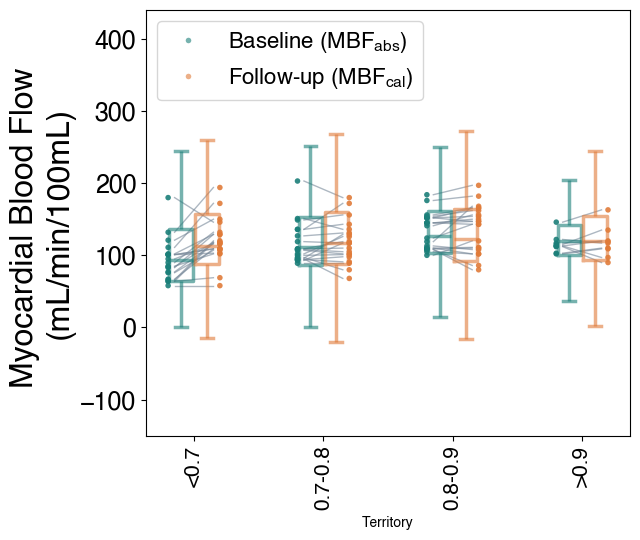

In [85]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2}, legend=False)#, boxprops=dict(alpha=0.4))
sns.stripplot(x='Territory', y='MBF', hue='Type', data= df_long2, dodge=True, jitter=False, alpha=0.9, size=4, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})
#ax = plt.gca()

# Group by territory to iterate over the 4 categorical columns
for i, territory in enumerate(df_long2['Territory'].unique()):
    df_terr = df_long2[df_long2['Territory'] == territory]
    
    # Pair up every unique patient ID within this territory
    for pid in df_terr['ID'].unique():
        pair = df_terr[df_terr['ID'] == pid]
        
        # Verify both pre and post points exist for the ID
        if len(pair) == 2:
            val_base = pair[pair['Type'].str.contains('Baseline')]['MBF'].values[0]
            val_foll = pair[pair['Type'].str.contains('Follow-up')]['MBF'].values[0]
            
            # Compute shifted x positions matching the 0.3 dodge factor
            x_base = i - 0.15 
            x_foll = i + 0.15
            
            # Draw the connecting paired line
            ax.plot([x_base, x_foll], [val_base, val_foll], color='lightslategray', alpha=0.6, linewidth=1, zorder=1)

plt.setp(ax.lines, alpha=0.6)
ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,440)
plt.tight_layout()
plt.show()

In [94]:
df[df['patient_id'] == 'SU13']

,patient_id,tag,graft_type,is_ischemic,ischemic_grade,graft_stenosis,absMBF_A,absMBF_B,median_A,median_B
26,SU13,LAD,LIMA,True,2,0,"[119.0, 119.0, 119.0, 119.0, 110.0, 106.0, 114...","[41.0, 22.0, 50.0, 34.0, 152.0, 146.0, 154.0, ...",102.0,126.0
27,SU13,LCx,SVG,False,0,0,"[142.0, 125.0, 119.0, 116.0, 117.0, 117.0, 118...","[216.0, 205.0, 219.0, 212.0, 211.0, 221.0, 213...",146.0,163.0
28,SU13,RCA,SVG,False,1,0,"[96.0, 93.0, 112.0, 111.0, 106.0, 106.0, 108.0...","[105.0, 156.0, 49.0, 198.0, 224.0, 238.0, 213....",124.0,143.0
29,SU13,Non-grafted\nstenosis<50%,NaN,False,0,0,"[37.0, 40.0, 40.0, 42.0, 45.0, 47.0, 45.0, 45....","[255.0, 158.0, 203.0, 97.0, 127.0, 147.0, 120....",136.0,136.0
